# Visualize Resource Log CSV

This notebook loads and visualizes time-series resource monitoring data from a CSV file. We will use `pandas` for data manipulation and `matplotlib` for plotting.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import io

# Configure plots to appear inline in the notebook
%matplotlib inline

## 1. Load the Data

Update the `file_path` variable in the next cell to point to your `.csv` file.

In [31]:
# --- IMPORTANT ---
# Change this variable to the actual path of your CSV file
file_path = 'training_stats/memory_profile_2025-10-30_15-46-37.csv'
# -----------------

try:
    df = pd.read_csv(file_path)
    print("File loaded successfully.")
    print("\nDataFrame Info:")
    df.info()
    print("\nDataFrame Head:")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file was not found at the path: {file_path}")
    print("Please make sure the file is in the same directory as the notebook, or provide the full path.")
    df = None  # Set df to None so subsequent cells don't error
except Exception as e:
    print(f"An error occurred while reading the file: {e}")
    df = None

File loaded successfully.

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 434 entries, 0 to 433
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   timestamp_utc        434 non-null    object 
 1   elapsed_s            434 non-null    float64
 2   rss_mb               434 non-null    float64
 3   cuda_available       434 non-null    int64  
 4   cuda_allocated_mb    0 non-null      float64
 5   cuda_reserved_mb     0 non-null      float64
 6   nvidia_mem_used_mb   0 non-null      float64
 7   nvidia_mem_total_mb  0 non-null      float64
 8   gpu_util_percent     0 non-null      float64
dtypes: float64(7), int64(1), object(1)
memory usage: 30.6+ KB

DataFrame Head:


,timestamp_utc,elapsed_s,rss_mb,cuda_available,cuda_allocated_mb,cuda_reserved_mb,nvidia_mem_used_mb,nvidia_mem_total_mb,gpu_util_percent
0,2025-10-30T07:46:37.146164,0.000,310.422,0,NaN,NaN,NaN,NaN,NaN
1,2025-10-30T07:46:38.165628,1.020,341.172,0,NaN,NaN,NaN,NaN,NaN
2,2025-10-30T07:46:39.183475,2.037,346.625,0,NaN,NaN,NaN,NaN,NaN
3,2025-10-30T07:46:40.197940,3.052,346.547,0,NaN,NaN,NaN,NaN,NaN
4,2025-10-30T07:46:41.209176,4.063,346.609,0,NaN,NaN,NaN,NaN,NaN


## 2. Prepare Data for Plotting

For time-series plotting, it's best to convert the `timestamp_utc` column to proper datetime objects and set it as the DataFrame's index. This gives us a time-based x-axis.

In [32]:
# This block will only run if the file was loaded successfully
if df is not None:
    # pd.to_datetime can error on bad data (like the '2B25...' in the original sample).
    # We add errors='coerce' to gracefully handle this by turning invalid dates into NaT (Not a Time).
    df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'], errors='coerce')

    # We'll drop any rows that failed to parse, just to be clean.
    df.dropna(subset=['timestamp_utc'], inplace=True)

    df.set_index('timestamp_utc', inplace=True)

    print("DataFrame after setting timestamp index:")
    display(df.head())
else:
    print("DataFrame not loaded. Skipping data preparation.")

DataFrame after setting timestamp index:


,elapsed_s,rss_mb,cuda_available,cuda_allocated_mb,cuda_reserved_mb,nvidia_mem_used_mb,nvidia_mem_total_mb,gpu_util_percent
timestamp_utc,,,,,,,,
2025-10-30 07:46:37.146164,0.000,310.422,0,NaN,NaN,NaN,NaN,NaN
2025-10-30 07:46:38.165628,1.020,341.172,0,NaN,NaN,NaN,NaN,NaN
2025-10-30 07:46:39.183475,2.037,346.625,0,NaN,NaN,NaN,NaN,NaN
2025-10-30 07:46:40.197940,3.052,346.547,0,NaN,NaN,NaN,NaN,NaN
2025-10-30 07:46:41.209176,4.063,346.609,0,NaN,NaN,NaN,NaN,NaN


## 3. Visualize the Data

### Plot 1: RSS Memory (rss_mb) Over Time

Let's plot the `rss_mb` column. This shows how memory usage changed over the logging period.

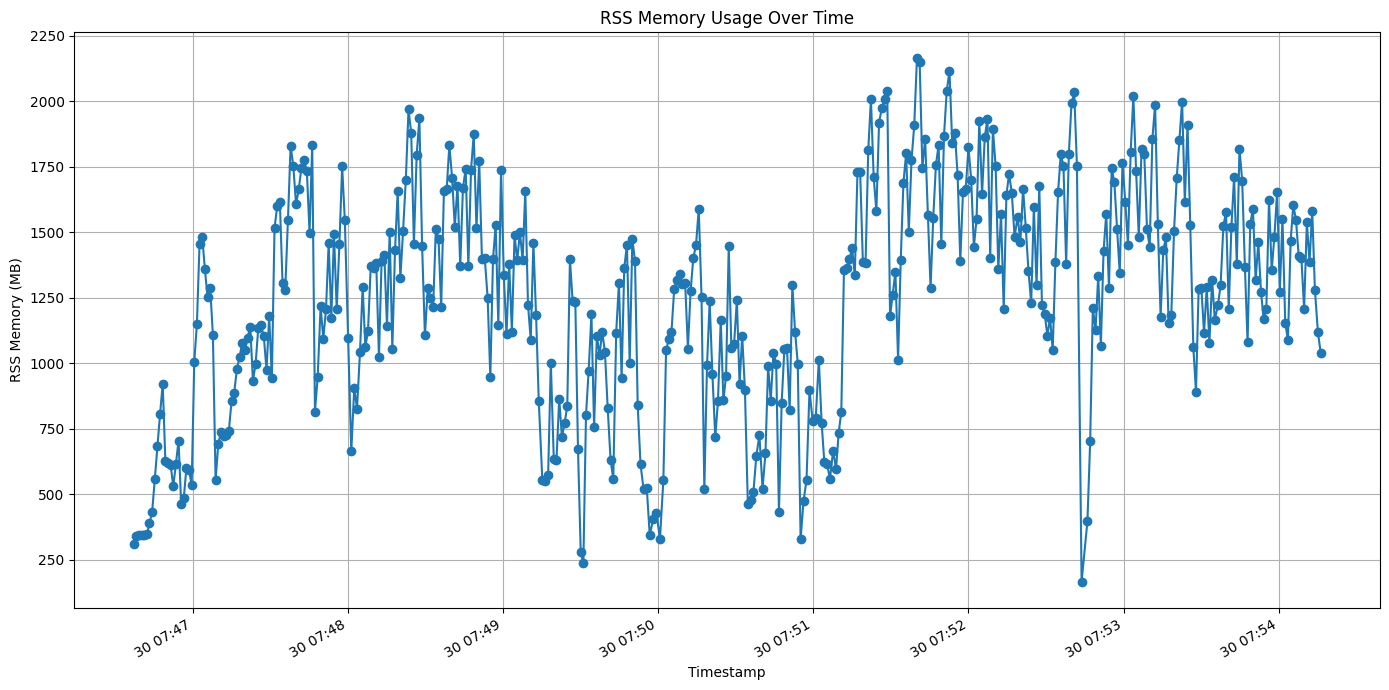

In [33]:
if df is not None and 'rss_mb' in df.columns:
    plt.figure(figsize=(14, 7))
    df['rss_mb'].plot(title='RSS Memory Usage Over Time', grid=True, marker='o', linestyle='-')
    plt.xlabel('Timestamp')
    plt.ylabel('RSS Memory (MB)')
    plt.tight_layout() # Adjusts plot to prevent labels from overlapping
    plt.show()
elif df is not None:
    print("Column 'rss_mb' not found in DataFrame.")
else:
    print("DataFrame not loaded. Skipping plot 1.")

### Plot 2: All Numeric Columns

We can also plot all available numeric columns at once. Using `subplots=True` creates a separate small chart for each metric.

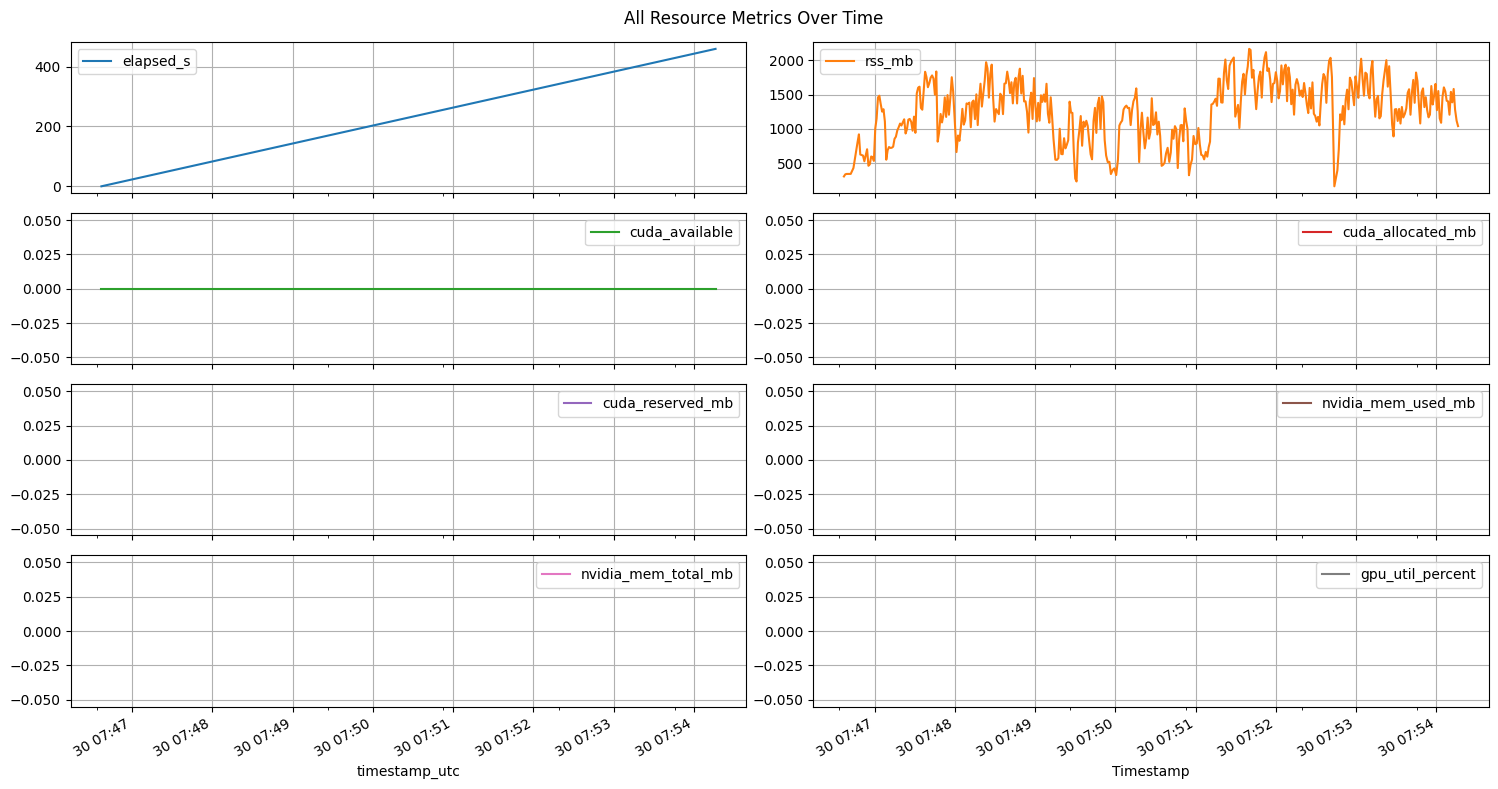

In [34]:
if df is not None:
    # Select only columns with numeric data
    numeric_cols = df.select_dtypes(include='number')

    if not numeric_cols.empty:
        # `subplots=True` creates a chart for each column
        # `layout=(-1, 2)` arranges them in a grid with 2 columns
        numeric_cols.plot(figsize=(15, 8), subplots=True, layout=(-1, 2), title='All Resource Metrics Over Time', grid=True)
        
        plt.xlabel('Timestamp') # Applies label to the bottom-most plots
        plt.tight_layout()
        plt.show()
    else:
        print("No numeric data to plot after setting index.")
else:
    print("DataFrame not loaded. Skipping plot 2.")